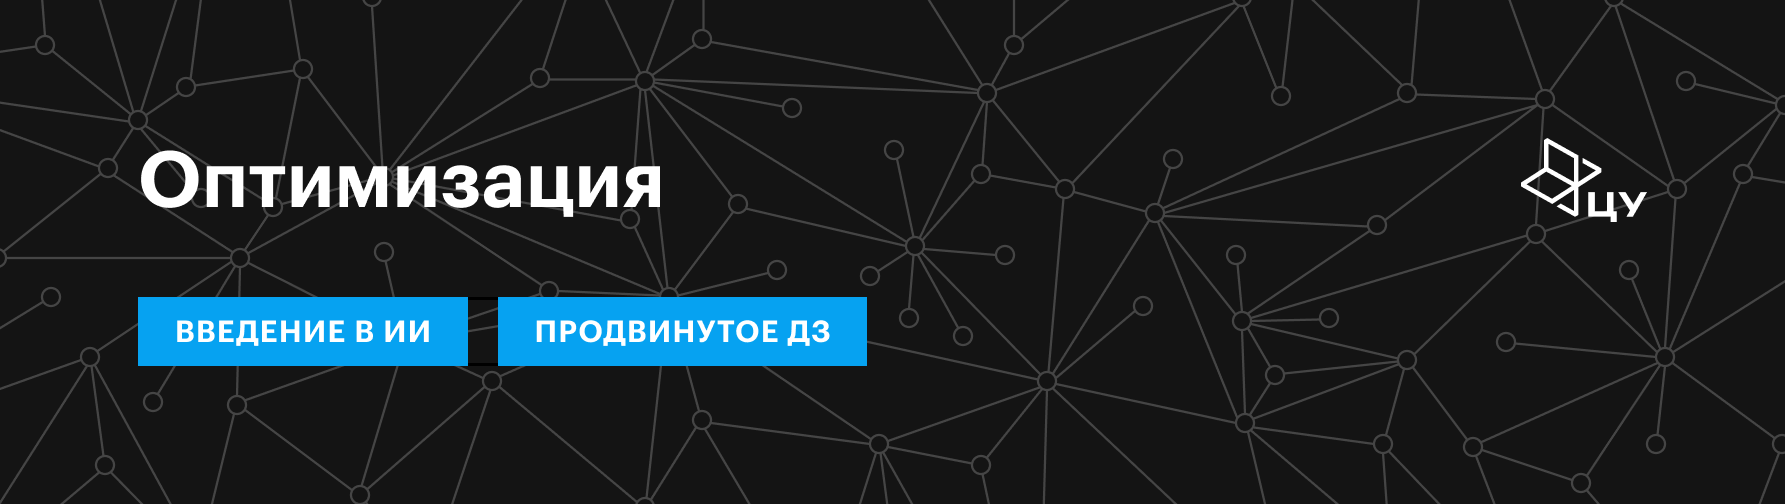

# Домашнее задание по теме «Неградиентная оптимизация»

Когда градиент недоступен или его сложно вычислить, применяют неградиентные методы оптимизации. В этом домашнем задании ты реализуешь один из популярных методов неградиентной оптимизации — метод имитации отжига.

> ### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
 > 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.
>
> 7. Если используешь случайность — фиксируй seed.


## Импорты и настройки

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Алгоритм имитации отжига

> **Метод имитации отжига** — это стохастический метод глобальной оптимизации, вдохновлённый физическим процессом отжига (англ. annealing): при высокой температуре система легко перескакивает между состояниями, а при охлаждении «застывает» в низкоэнергетическом состоянии.



### Идея
Пусть нужно минимизировать функцию $f(x)$ — в 1D или многомерном случае. Для этого генерируем кандидата $x'$, сравниваем $f(x')$ с текущим $f(x)$:
- если $f(x') \le f(x)$ — **принимаем улучшение**;
- если $f(x') > f(x)$ — **иногда тоже принимаем**, чтобы выходить из локальных минимумов.

Вероятность принять ухудшение задаётся так:

$$p = \exp\left(-\frac{\Delta f}{T}\right), \quad \Delta f = f(x') - f(x),\quad T>0.$$
Здесь чем выше температура $T$, тем легче принимать ухудшения.

### Компоненты алгоритма
1. **Правило генерации кандидата (proposal)**:
    - получить новую точку $x'$ из текущей $x$, добавляя к ней случайный шаг $\varepsilon$: $x' = x + \varepsilon$;
    - выбрать шаг $\varepsilon$ равномерно или брать из нормального распределения:$\quad \varepsilon \sim \text{(например) } \mathcal{N}(0,\sigma^2)$;
    - можно сделать шаг $\sigma$ зависимым от температуры.

2) **Температурный режим (cooling schedule)**:
    - геометрический: $T_{k+1}=\alpha T_k$, $\alpha\in(0,1)$ — самый популярный;
    - логарифмический: $T_k = \frac{T_0}{\log(2+k)}$ — теоретически «сильнее», но часто медленнее на практике.

3) **Критерий остановки**: число итераций, минимальная температура, отсутствие улучшений и так далее.

    >**Важно.** В данном домашнем задании в качестве критерия остановки лучше использовать ограничение по числу итераций.

### Псевдокод
```
выбрать x0, T0, alpha, n_iters
x = x0
best = x
for k in range(n_iters):
    сгенерировать x_candidate рядом с x
    df = f(x_candidate) - f(x)
    if df <= 0: принять
    else: принять с вероятностью exp(-df/T)
    обновить best
    T = alpha * T
вернуть best
```


## Задание 1 [0,5 балла]

Реализуй 2D-функцию Ackley:
$$f(x,y) = -20\exp\Big(-0.2\sqrt{0.5(x^2+y^2)}\Big)
        -\exp\Big(0.5(\cos(2\pi x)+\cos(2\pi y))\Big)
        + e + 20.$$

Функция имеет глобальный минимум в точке $(0,0)$ со значением $0$ и множество локальных минимумов.

In [3]:
def ackley(xy, a=20.0, b=0.2, c=2*np.pi):
    x, y = float(xy[0]), float(xy[1])
    f = -20 * np.exp(-0.2 * (np.sqrt(0.5 * (x * x + y * y)))) - np.exp(0.5 * (np.cos(2 * np.pi * x)) + np.cos(2 * np.pi * y)) + np.e + 20

    return f

## Задание 2 [1,5 балла + 1 бонусный балл]

Реализуй градиент Ackley в точке.

1) Реализуй аналитический градиент $\nabla f(x,y)$ — **[1,5 балла].**

>**Подсказка.** Аккуратно обработай точку $(0,0)$ — в формуле есть деление на $\sqrt{x^2+y^2}$. Можно добавить маленький `eps`.

2) **Бонусное задание.** Реализуй вычисление градиента через библиотеку автоматического дифференцирования (AD). Например, через `torch.autograd`, `jax` или другую библиотеку, позволяющую аналитически вычислять производные — **[1 бонусный балл].**

In [4]:
def grad_ackley(xy):
    x, y = float(xy[0]), float(xy[1])

    viperr = (np.sqrt(0.5 * (x * x + y * y)))
    viperr += 1e-10

    dx = 2 * np.exp(-0.2*(viperr)) * x / viperr + np.pi * np.exp(0.5 * (np.cos(2 * np.pi * x)) + np.cos(2 * np.pi * y)) * np.sin(2*np.pi*x)
    dy = 2 * np.exp(-0.2*(viperr)) * y / viperr + np.pi * np.exp(0.5 * (np.cos(2 * np.pi * x)) + np.cos(2 * np.pi * y)) * np.sin(2*np.pi*y)

    return np.array(dx, dy)

In [5]:
import torch

def grad_ackley(xy):
    x = torch.tensor(xy[0], requires_grad=True, dtype=torch.float32)
    y = torch.tensor(xy[1], requires_grad=True, dtype=torch.float32)

    f = -20 * torch.exp(-0.2 * torch.sqrt(0.5 * (x**2 + y**2))) - torch.exp(0.5 * (torch.cos(2 * torch.pi * x) + torch.cos(2 * torch.pi * y))) + torch.e + 20
    f.backward()

    return np.array([x.grad.item(), y.grad.item()])


## Задание 3 [4 балла]

Реализуй метод имитации отжига (Simulated Annealing, SA) для минимизации функции двух переменных \(f(x,y)\).

1. Задай вход: функция \(f\), начальная точка $z_0\in\mathbb{R}^2$, начальная температура $T_0$, коэффициент охлаждения $\alpha$, число итераций, масштаб шага предложения `step_scale` и (опционально) ограничения по области поиска.
2. Создай выход: лучшую найденную точку и историю (траектория, значения функции, температура).


**Идея алгоритма.**
- Имеем текущую точку $z_k=(x_k,y_k)$.
- Предлагаем соседнюю точку $z' = z_k + \eta$, где $\eta$ — случайный шаг (например, двумерный гауссов шум).
- Если $f(z') \le f(z_k)$, то принимаем $z'$.
- Если $f(z') > f(z_k)$, то принимаем $z'$ с вероятностью
$p = \exp\left(-\frac{f(z')-f(z_k)}{T}\right)$.
- Температура $T$ постепенно уменьшается — например, $T_{k+1}=\alpha T_k$, $\alpha\in(0,1)$.

>**Важно.** В данном домашнем задании лучше в качестве критерия остановки использовать ограничение по числу итераций.

In [23]:
def simulated_annealing_2d(f, z0, T0=1.0, alpha=0.995, n_steps=50000, step_scale=0.5):

    hist = {
        "z": [],
        "f": [],
        "T": [],
        "accepted": []
    }

    z = np.array(z0)
    T = T0

    best_z = z.copy()
    best_f = f(z)

    for i in range(n_steps):
        step = np.random.normal(0, step_scale, size=2)
        z1 = z + step

        f_old = f(z)
        f_new = f(z1)

        df = f_new - f_old

        accepted = False
        if df <= 0 or np.random.rand() < np.exp(-df / T):
            z = z1
            accepted = True

        current_f = f(z)
        if current_f < best_f:
            best_f = current_f
            best_z = z.copy()

        hist["z"].append(z.copy())
        hist["f"].append(current_f)
        hist["T"].append(T)
        hist["accepted"].append(accepted)

        T *= alpha

    return best_z, best_f, hist

## Задание 4 [1 балл]

1. Построй контурный график $f(x,y)$ для Ackley на области $[-5,5]\times[-5,5]$ — **[0,5 балла]**.

2. Ответь на вопрос: какие особенности есть у данной поверхности? **[0,5 балла].**

>**Подсказка.** Для более красивой картинки можешь воспользоваться методом [plt.contour](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html).



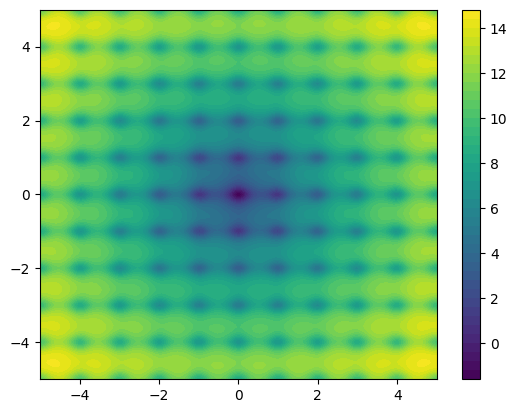

In [24]:
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)

Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = ackley([X[i, j], Y[i, j]])

plt.contourf(X, Y, Z, levels=50)
plt.colorbar()

#### Функция имеет множество локальных минимумов, а также постепенно уменьшается по мере приближения к 0, 0. И на 0, 0 как раз локальный минимум. Функция постоянно уменьшается и увеличивается, не имеет плато

## Задание 5 [0,5 балла]

В области $[-5,5]\times[-5,5]$ запусти написанный тобой алгоритм из точки $(4,-4)$ и посмотри, куда он сойдётся — **[0,5 балла]**.
1) Выведи лучшую точку и значение функции.
2) Нарисуй траекторию на контурном графике.
3) Нарисуй график $f(z_k)$ по итерациям.


In [25]:
best_z, best_f, hist = simulated_annealing_2d(ackley, (4, -4), )

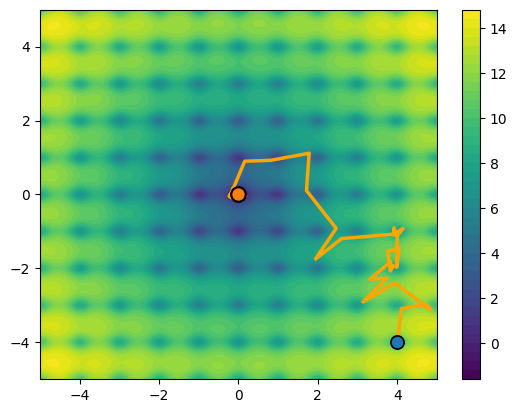

In [26]:
Xhist, Yhist = best_z
best_z, best_f

traj = np.array(hist['z'])
plt.scatter([traj[0, 0]], [traj[0, 1]], s=90, c=["tab:blue"], edgecolors=["black"], linewidths=1.2, zorder=12, label="start")
plt.scatter([traj[-1, 0]], [traj[-1, 1]], s=110, c=["tab:orange"], edgecolors=["black"], linewidths=1.6, zorder=13, label="end")

plt.plot(traj[:, 0], traj[:, 1], color="orange", linewidth=2.5, zorder=10)

plt.contourf(X, Y, Z, levels=50)
plt.colorbar()

## Задание 6 [2,5 балла]

Проведи эксперименты и сравни Ackley с градиентным спуском.


1) Поэкспериментируй — **[1 балл]**:
- разными начальными точками $z_0$;
- температурой $T_0$;
- скоростью охлаждения $\alpha$;
- масштабом шага `step_scale`.

2) Сравни SA с градиентным спуском (GD) на Ackley — **[1,5 балла]**:
- запусти GD из разных стартов;
- сравни, насколько часто или быстро методы попадают в район глобального минимума.

>**Подсказка.** Используй GD из семинара (функция ниже).

**Примечание к заданию:**

- необходимо провести как минимум 6 экспериментов — запусков какого-то алгоритма из разных точек;
- выводы должны согласовываться с результатами экспериментов.


In [27]:
# Функция с семинара

def gradient_descent(f, grad_f, x0, lr, n_steps=10_000, tol=1e-10):
    x = np.array(x0, dtype=float)
    history = {"x": [], "f": []}

    for t in range(n_steps):
        fx = float(f(x))
        g  = np.array(grad_f(x), dtype=float)

        history["x"].append(x.copy())
        history["f"].append(fx)

        x_new = x - lr * g

        # Критерий остановки по маленькому шагу
        if np.linalg.norm(x_new - x) < tol:
            x = x_new
            break

        x = x_new

    return x, history


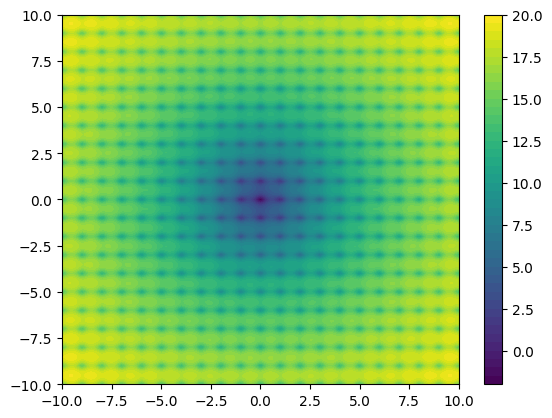

In [37]:
x = np.linspace(-10, 10, 800)
y = np.linspace(-10, 10, 800)
X, Y = np.meshgrid(x, y)

Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = ackley([X[i, j], Y[i, j]])

plt.contourf(X, Y, Z, levels=50)
plt.colorbar()

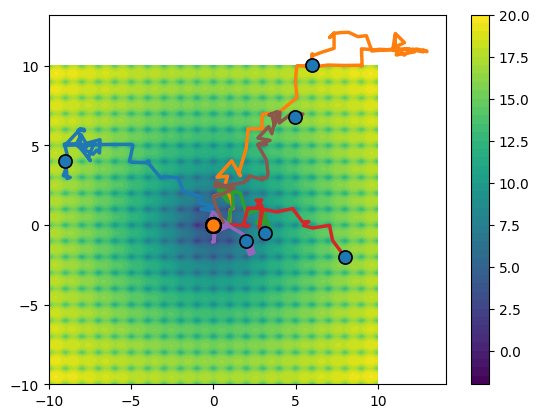

In [44]:
dots = ((-9, 4), (6, 9.5), (3.5, 0), (8, -2), (2, -1), (5, 7))

for i in dots:
    best_z, best_f, hist = simulated_annealing_2d(ackley, i)
    Xhist, Yhist = best_z

    traj = np.array(hist['z'])

    plt.plot(traj[:, 0], traj[:, 1], linewidth=2.5, zorder=10)

    plt.scatter(traj[0, 0], traj[0, 1],
                s=90, c="tab:blue", edgecolors="black", linewidths=1.2, zorder=12)

    plt.scatter(traj[-1, 0], traj[-1, 1],
                s=110, c="tab:orange", edgecolors="black", linewidths=1.6, zorder=13)

plt.contourf(X, Y, Z, levels=50)
plt.colorbar()

Тут уходит, но всегда приходит. Если поставить далеко, не хватит охлаждения

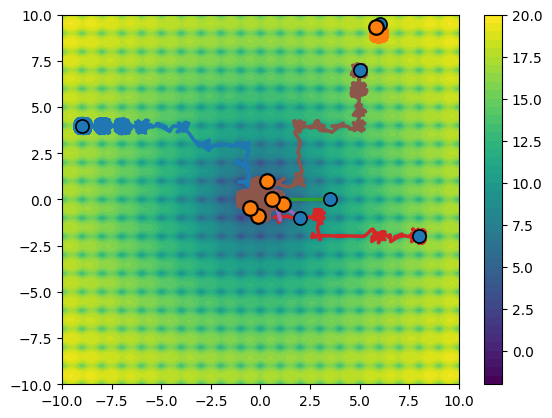

In [39]:
dots = ((-9, 4), (6, 9.5), (3.5, 0), (8, -2), (2, -1), (5, 7))

for i in dots:
    best_z, hist = gradient_descent(ackley, grad_ackley, i, 0.1)
    Xhist, Yhist = best_z

    traj = np.array(hist['x'])

    plt.plot(traj[:, 0], traj[:, 1], linewidth=2.5, zorder=10)

    plt.scatter(traj[0, 0], traj[0, 1],
                s=90, c="tab:blue", edgecolors="black", linewidths=1.2, zorder=12)

    plt.scatter(traj[-1, 0], traj[-1, 1],
                s=110, c="tab:orange", edgecolors="black", linewidths=1.6, zorder=13)

plt.contourf(X, Y, Z, levels=50)
plt.colorbar()

По градиентному, как видно, с learning rate 0.1 не всегда доходит до нужной точки. Думаю, для далеких точек надо ставить больше. Ща попробуем


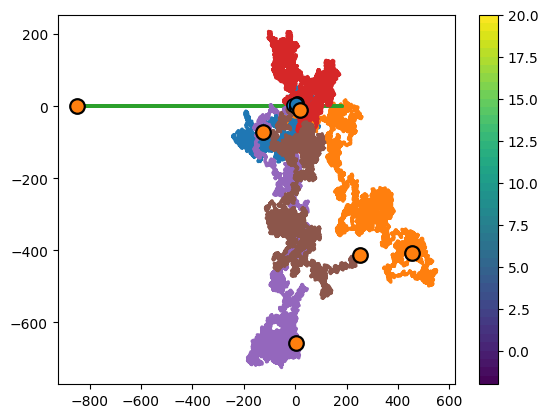

In [40]:
dots = ((-9, 4), (6, 9.5), (3.5, 0), (8, -2), (2, -1), (5, 7))

for i in dots:
    best_z, hist = gradient_descent(ackley, grad_ackley, i, 1)
    Xhist, Yhist = best_z

    traj = np.array(hist['x'])

    plt.plot(traj[:, 0], traj[:, 1], linewidth=2.5, zorder=10)

    plt.scatter(traj[0, 0], traj[0, 1],
                s=90, c="tab:blue", edgecolors="black", linewidths=1.2, zorder=12)

    plt.scatter(traj[-1, 0], traj[-1, 1],
                s=110, c="tab:orange", edgecolors="black", linewidths=1.6, zorder=13)

plt.contourf(X, Y, Z, levels=50)
plt.colorbar()

Тут вообще уходит далеко, надо подбирать лучше